In [2]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import time
from functools import reduce
import matplotlib.pyplot as plt
from shapely.geometry import box, MultiPolygon

import parreg.process_config as pc
from parreg import funcs_clust, funcs_dist
from parreg.logging_config import setup_logging

setup_logging()

import logging

logger = logging.getLogger(__name__)

In [ ]:
# read and validate config
config_file = Path(
    "/home/yuqiong.liu/work/Gitlab/ngen-regionalization/configs/config.yaml"
)
if not config_file.exists():
    raise FileNotFoundError(config_file)

config = pc.load_and_validate_config(config_file)

In [ ]:
# process by VPU
vpu = config.general.vpu_list[0]

In [ ]:
# get receivers and qualified donors in the VPU, and compute pairwise spatial distances between them
donors, receivers, df_dist_spatial = pc.get_donors_receivers(config, vpu)

In [ ]:
# assemble the attribute data for donors and receivers
donors, receivers, df_attrs_all = pc.process_attr_data(
    config, vpu, donors, receivers, df_dist_spatial
)

In [ ]:
# detemine whether the catchments are snowy (as snowy and non-snowy catchments are processed separately)
df_attrs_all = pc.set_snow_flag(df_attrs_all, config.algorithms.general.min_snow_frac)

In [ ]:
# loop through regionalization algorithms to generate donor-receiver pairings
pc.generate_pairing(config, vpu, df_attrs_all, df_dist_spatial)

In [53]:
file = "/home/yuqiong.liu/work/data/ngen_reg/inputs/formulation_stats/stat_calval_nom-ueb-sac_conus.csv"
df1 = pd.read_csv(file, dtype={"gage_id": str, "vpuid": str, "evalPeriod": str})
df1 = df1[
    (df1["vpuid"] == "01")
    & (df1["evalPeriod"] == "valid")
    & (df1["gage_id"] == "01010000")
]
print(df1.head())

    gage_id  formulation   latitude  longitude vpuid evalPeriod       bias  \
2  01010000  nom-ueb-sac  46.700556 -69.715556    01      valid  11.533404   

       rmse       cor       nse  ...     lbem  lbemprime     corr1       pod  \
2  6.186897  0.590101  0.263171  ... -0.21004   0.403342  0.605595  0.418848   

       far       csi      nnse  peak_bias  peak_tm_err_hr  event_volume_bias  
2  0.55836  0.273839  0.575762  54.499296        9.210526          64.790314  

[1 rows x 27 columns]


In [63]:
file = "/home/yuqiong.liu/work/data/ngen_reg/inputs/cwt_ngen_huc12/cwt_huc12_divide_conus.csv"
df1 = pd.read_csv(file, dtype={"huc12": str})
df1.sort_values(by=["overlap_percentage"], inplace=True)
print(df1[df1["divide_id"] == "cat-646627"])

         divide_id         huc12  overlap_area  areasqkm  original_area  \
134691  cat-646627  040101010208          0.41    777.13        1745.25   

        overlap_percentage  nearest_dist_m  
134691                0.02             NaN  


In [64]:
# summary of "overlap_percentage"
print(df1["overlap_percentage"].describe())

count    831665.000000
mean         98.720536
std           5.534614
min           0.020000
25%          99.460000
50%          99.670000
75%          99.850000
max         100.000000
Name: overlap_percentage, dtype: float64


In [ ]:
import fiona

gpkg_path = "/home/yuqiong.liu/work/data/gpkg_v2.2/conus_nextgen.gpkg"
layer = "divides"

ids = df1[df1["overlap_percentage"] < 0.9]["divide_id"].unique()

with fiona.open(gpkg_path, layer=layer) as src:
    features = [feature for feature in src if feature["properties"]["divide_id"] in ids]
    gdf = gpd.GeoDataFrame.from_features(features, crs=src.crs)

EPSG:5070


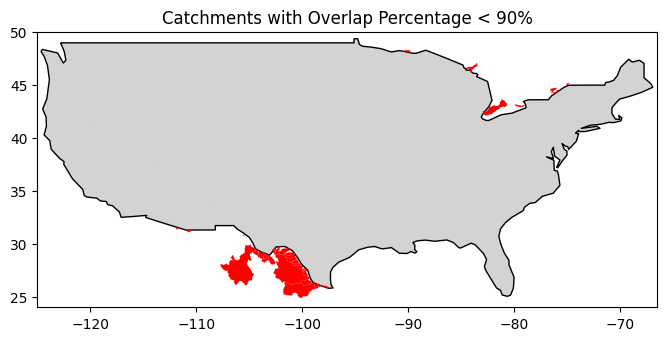

In [ ]:
# plot the catchments with overlap percentage < 90%
# Load world country shapes
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Filter for USA and convert CRS
usa = world[world["ADMIN"] == "United States of America"].to_crs(epsg=4326)

# Explode multipolygon into separate parts
usa_parts = usa.explode(index_parts=False, ignore_index=True)

# Define CONUS bounding box
conus_bounds = box(-125, 24, -66.5, 50)

# Keep only geometries that intersect the CONUS bounds
conus = usa_parts[usa_parts.intersects(conus_bounds)]

# Reproject your gdf to same CRS if not already
gdf = gdf.to_crs(epsg=4326)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
conus.plot(ax=ax, color="lightgray", edgecolor="black")
gdf.plot(ax=ax, color="red", markersize=1)

# Limit to CONUS
ax.set_xlim(-125, -66.5)
ax.set_ylim(24, 50)

ax.set_title("Catchments with Overlap Percentage < 90%")
ax.set_aspect("equal")
plt.show()

In [97]:
# check number of divides in cwt_divide_huc12 for vpu 01
cwt_divide_huc12 = pd.read_csv(
    "/home/yuqiong.liu/work/data/ngen_reg/inputs/cwt_ngen_huc12/cwt_huc12_divide_conus.csv",
    dtype={"huc12": str, "divide_id": str, "vpu": str},
)
cwt_divide_huc12["vpuid"] = cwt_divide_huc12["huc12"].str[:2]
cwt_divide_huc12 = cwt_divide_huc12[cwt_divide_huc12["vpuid"] == "01"].copy()
print(
    f"Number of divides in cwt_divide_huc12 for vpu 01: {len(cwt_divide_huc12['divide_id'].unique())}"
)

Number of divides in cwt_divide_huc12 for vpu 01: 20394


In [98]:
# add huc8 column to cwt_divide_huc12
cwt_divide_huc12["huc8"] = cwt_divide_huc12["huc12"].str[:8]
print(
    f"Number of unique huc8 in cwt_divide_huc12 for vpu 01: {len(cwt_divide_huc12['huc8'].unique())}"
)

Number of unique huc8 in cwt_divide_huc12 for vpu 01: 58


In [101]:
x = list(range(10))
y = [i**2 for i in x]
x1 = [1, 2, 3, 4, 5]
print(f"x: {x}\ny: {y}\nx1: {x1}")

x: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
y: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
x1: [1, 2, 3, 4, 5]


In [104]:
x, y = map(list, zip(*[(i, j) for i, j in zip(x, y) if i in x1]) if x else ([], []))
print(f"x: {x}\ny: {y}")

x: [1, 2, 3, 4, 5]
y: [1, 4, 9, 16, 25]


In [108]:
file1 = "/home/yuqiong.liu/work/data/ngen_reg/outputs/test1/summary_score/score_conus_vpu01.parquet"
df1 = pd.read_parquet(file1, dtype_backend="pyarrow")
print(df1.head())

    gage_id       formulation  summary_score
0  01010000  nom-snow17-lasam       0.693032
1  01011000  nom-snow17-lasam       0.680572
2  01013500  nom-snow17-lasam       0.324508
3  01015800  nom-snow17-lasam        0.42932
4  01021480  nom-snow17-lasam       0.765975


In [ ]:
col1 = "gage_id"
max_scores = df1.groupby(col1)["summary_score"].transform("max")
best_per_gage = df1[df1["summary_score"] >= (max_scores - max_scores * 0.05)]
print(len(max_scores))
print(len(df1))
print(f"unique number of gage_ids: {len(df1['gage_id'].unique())}")
print(len(best_per_gage))
print(best_per_gage[best_per_gage["gage_id"] == "01010000"])
print(0.725031 - 0.725031 * 0.05)
print(best_per_gage["gage_id"].value_counts())

In [ ]:
x = "test"
x1 = set(x)
print(x1)

In [35]:
# read from the old and new parquet files and compare
file_old = "~/repos/nwm-region-mgr/data/inputs/cwt_divide_gage.old/calib_gage_divide_conus.parquet"
file_new = "~/repos/nwm-region-mgr/data/inputs/cwt_divide_gage/calib_gage_divide_conus.parquet"
df_old = pd.read_parquet(file_old, dtype_backend="pyarrow")
df_new = pd.read_parquet(file_new, dtype_backend="pyarrow")


In [31]:
# filter to vpu 01
df_old = df_old[df_old["vpuid"] == "01"].copy()
df_new = df_new[df_new["vpuid"] == "01"].copy()

In [19]:
print(f"old: {len(df_old)}, new: {len(df_new)}")
print(f"Number of divides: old: {len(set(df_old['divide_id']))}, new: {len(set(df_new['divide_id']))}")
print(f"Number of gages in old but not in new: {len(set(df_old['gage_id']) - set(df_new['gage_id']))}")
print(f"gages in old but not in new: {set(df_old['gage_id']) - set(df_new['gage_id'])}")
print(f"number of divides in old but not in new: {len(set(df_old['divide_id']) - set(df_new['divide_id']))}")

old: 4905, new: 4559
Number of divides: old: 4559, new: 4559
Number of gages in old but not in new: 1
gages in old but not in new: {'01194000'}
number of divides in old but not in new: 0


In [20]:
gage = "01194000"
print(f"Number of records for gage {gage} in old: {len(df_old[df_old['gage_id'] == gage])}")
print(f"Number of records for gage {gage} in new: {len(df_new[df_new['gage_id'] == gage])}")

Number of records for gage 01194000 in old: 15
Number of records for gage 01194000 in new: 0


In [ ]:
# identify rows in old but not in new
df_merged = df_old.merge(df_new, on=["gage_id", "divide_id"], how="left", indicator=True)
df_diff = df_merged[df_merged["_merge"] == "left_only"]
print(f"Number of rows in old but not in new: {len(df_diff)}")
print(f"Number of unique gages in old but not in new: {len(df_diff['gage_id'].unique())}")
print(df_diff)

In [ ]:
df_old_temp = df_old[df_old["gage_id"] == "01029500"]
df_new_temp = df_new[df_new["gage_id"] == "01029500"]
print(len(df_old_temp))
print(len(df_new_temp))

# find rows in old but not in new for gage 01029500
df_merged_temp = df_old_temp.merge(df_new_temp, on=["gage_id", "divide_id"], how="left", indicator=True)
df_diff_temp = df_merged_temp[df_merged_temp["_merge"] == "left_only"]
print(df_diff_temp)

In [24]:
print(df_old[df_old["divide_id"]== "cat-1177"])
print(df_new[df_new["divide_id"]== "cat-1177"])

        gage_id divide_id      toid  areasqkm vpuid     type
44     01029200  cat-1177  nex-1178  19.73925    01  network
28439  01029500  cat-1177  nex-1178  19.73925    01  network
         gage_id divide_id      toid  areasqkm vpuid     type
131396  01029200  cat-1177  nex-1178  19.73925    01  network


In [47]:
# read old and new csv files storing divide ids and compare
file_old = "~/repos/nwm-region-mgr/data/logs/non_snowy_cats_old.csv"
file_new = "~/repos/nwm-region-mgr/data/logs/non_snowy_cats_new.csv"
df_cats_old = pd.read_csv(file_old, header=0, dtype=str)
df_cats_new = pd.read_csv(file_new, header=0, dtype=str)
cats_old = df_cats_old.columns.tolist()
cats_new = df_cats_new.columns.tolist()

# remove quotes around each id in cats_old and cats_new if present
cats_old = [cat.strip(" '") for cat in cats_old]
cats_new = [cat.strip(" '") for cat in cats_new]
cats_old = [cat.strip(' "') for cat in cats_old]
cats_new = [cat.strip(' "') for cat in cats_new]
print(f"Number of non-snowy catchments in old: {len(cats_old)}, new: {len(cats_new)}")
print(f"Number of non-snowy catchments in both old and new: {len(set(cats_old) & set(cats_new))}")
print(f"Number of non-snowy catchments in old but not in new: {len(set(cats_old) - set(cats_new))}")
print(f"Number of non-snowy catchments in new but not in old: {len(set(cats_new) - set(cats_old))}")
print(f"Non-snowy catchments in old but not in new: {set(cats_old) - set(cats_new)}")
print(f"Non-snowy catchments in new but not in old: {set(cats_new) - set(cats_old)}")

Number of non-snowy catchments in old: 745, new: 760
Number of non-snowy catchments in both old and new: 745
Number of non-snowy catchments in old but not in new: 0
Number of non-snowy catchments in new but not in old: 15
Non-snowy catchments in old but not in new: set()
Non-snowy catchments in new but not in old: {'cat-18017', 'cat-18018', 'cat-18009', 'cat-17997', 'cat-18010', 'cat-18014', 'cat-18007', 'cat-17998', 'cat-18012', 'cat-18015', 'cat-18011', 'cat-18016', 'cat-18008', 'cat-18013', 'cat-18006'}


In [38]:
# read from the old and new parquet files and compare
file_old = "~/repos/nwm-region-mgr/data/inputs/cwt_divide_gage.old/calib_gage_divide_conus.parquet"
file_new = "~/repos/nwm-region-mgr/data/inputs/cwt_divide_gage/calib_gage_divide_conus.parquet"
df_old = pd.read_parquet(file_old, dtype_backend="pyarrow")
df_new = pd.read_parquet(file_new, dtype_backend="pyarrow")


In [54]:
# identify rows in df_old and df_new where divide_id is in the set of non-snowy catchments in new but not in old
non_snowy_new = set(cats_new) - set(cats_old)
print(f"Non-snowy catchments in new but not in old: {sorted(non_snowy_new)}")
rows_old = df_old[df_old['divide_id'].isin(non_snowy_new)]
rows_new = df_new[df_new['divide_id'].isin(non_snowy_new)]
print(f"Number of rows in old: {len(rows_old)}, new: {len(rows_new)}")
print((rows_old[rows_old['divide_id']=='cat-17997']))
print((rows_new[rows_new['divide_id']=='cat-17997']))

Non-snowy catchments in new but not in old: ['cat-17997', 'cat-17998', 'cat-18006', 'cat-18007', 'cat-18008', 'cat-18009', 'cat-18010', 'cat-18011', 'cat-18012', 'cat-18013', 'cat-18014', 'cat-18015', 'cat-18016', 'cat-18017', 'cat-18018']
Number of rows in old: 30, new: 15
         gage_id  divide_id       toid  areasqkm vpuid     type
42075   01194500  cat-17997  nex-17998      8.46    01  network
100605  01194000  cat-17997  nex-17998      8.46    01  network
         gage_id  divide_id       toid  areasqkm vpuid     type
132900  01194500  cat-17997  nex-17998      8.46    01  network


In [78]:
file_cwt = "/home/yuqiong.liu/repos/nwm-region-mgr/data/inputs/cwt_divide_gage/calib_gage_divide_conus.parquet"
df_cwt = pd.read_parquet(file_cwt, dtype_backend="pyarrow")

file_form = "/home/yuqiong.liu/repos/nwm-region-mgr/data/outputs/test3/formulations/form_conus_vpu09.parquet"
df_form = pd.read_parquet(file_form, dtype_backend="pyarrow")
df_merged = df_cwt[["divide_id", "gage_id"]].merge(df_form[["divide_id", "formulation"]], 
                left_on="divide_id", right_on="divide_id", how="inner")
df_merged = df_merged.drop_duplicates()

In [79]:
# make sure each gage is associated with only one formulation
df_count = df_merged[['gage_id', "formulation"]].drop_duplicates().groupby("gage_id").size().reset_index(name="count").sort_values(by="count", ascending=False)
gages = df_count[df_count["count"] > 1]['gage_id'].tolist()
print(f"Number of gages associated with multiple formulations: {len(gages)}")
print(gages)

Number of gages associated with multiple formulations: 2
['05056200', '05123400']


In [80]:
print(df_form[df_form["divide_id"] == "cat-1502862"])

     vpu    divide_id                       formulation    huc_id  \
1269  09  cat-1502862  noah-owp-modular sac-sma t-route  09020316   

      total_score  summary_score  cost  num_gages upscale_huc  
1269         1.69       0.867569     8          3        huc6  


In [81]:
# loop through the gages associated with multiple formulations to reassign them to the most frequent formulation for both df_merged and df_form
for gage in gages:
    df1 = df_merged.loc[df_merged["gage_id"] == gage].sort_values(by="formulation")
    df_count = df1.groupby("formulation").size().reset_index(name="count").sort_values(by="count", ascending=False)
    most_freq_form = df_count.iloc[0]["formulation"]
    print(f"Gage {gage} is associated with multiple formulations, reassigning to the most frequent formulation {most_freq_form}")
    df_merged.loc[df_merged["gage_id"] == gage, "formulation"] = most_freq_form 
    df_form.loc[df_form["divide_id"].isin(df1["divide_id"]), "formulation"] = most_freq_form    

Gage 05056200 is associated with multiple formulations, reassigning to the most frequent formulation noah-owp-modular snow-17 sac-sma t-route
Gage 05123400 is associated with multiple formulations, reassigning to the most frequent formulation noah-owp-modular sac-sma t-route


In [82]:
print(df_form[df_form["divide_id"] == "cat-1502862"])

     vpu    divide_id                               formulation    huc_id  \
1269  09  cat-1502862  noah-owp-modular snow-17 sac-sma t-route  09020316   

      total_score  summary_score  cost  num_gages upscale_huc  
1269         1.69       0.867569     8          3        huc6  


In [74]:
print(df_merged)

        divide_id   gage_id                                formulation
0     cat-1502862  05056200   noah-owp-modular snow-17 sac-sma t-route
1     cat-1502812  05056200   noah-owp-modular snow-17 sac-sma t-route
2     cat-1502818  05056200   noah-owp-modular snow-17 sac-sma t-route
3     cat-1502819  05056200   noah-owp-modular snow-17 sac-sma t-route
4     cat-1502835  05056200   noah-owp-modular snow-17 sac-sma t-route
...           ...       ...                                        ...
3653  cat-1501013  05056000  noah-owp-modular snow-17 topmodel t-route
3654  cat-1501014  05056000  noah-owp-modular snow-17 topmodel t-route
3655  cat-1501015  05056000  noah-owp-modular snow-17 topmodel t-route
3656  cat-1501016  05056000  noah-owp-modular snow-17 topmodel t-route
3657  cat-1501017  05056000  noah-owp-modular snow-17 topmodel t-route

[3658 rows x 3 columns]


In [69]:
gage1 = "05056200"
#gage1 = "05123400"
df1 = df_merged.loc[df_merged["gage_id"] == gage1].sort_values(by="formulation")
df_count = df1.groupby("formulation").size().reset_index(name="count").sort_values(by="count", ascending=False)
print(df_count)
print(df1)

                                formulation  count
1  noah-owp-modular snow-17 sac-sma t-route     67
0          noah-owp-modular sac-sma t-route      3
      divide_id   gage_id                               formulation
0   cat-1502862  05056200          noah-owp-modular sac-sma t-route
45  cat-1502861  05056200          noah-owp-modular sac-sma t-route
46  cat-1502873  05056200          noah-owp-modular sac-sma t-route
1   cat-1502812  05056200  noah-owp-modular snow-17 sac-sma t-route
2   cat-1502818  05056200  noah-owp-modular snow-17 sac-sma t-route
..          ...       ...                                       ...
65  cat-1502843  05056200  noah-owp-modular snow-17 sac-sma t-route
66  cat-1502844  05056200  noah-owp-modular snow-17 sac-sma t-route
67  cat-1502839  05056200  noah-owp-modular snow-17 sac-sma t-route
68  cat-1502820  05056200  noah-owp-modular snow-17 sac-sma t-route
69  cat-1502834  05056200  noah-owp-modular snow-17 sac-sma t-route

[70 rows x 3 columns]


In [ ]:
# read gpkg
gdf_vpu = gpd.read_file(
    "/home/yuqiong.liu/data/hydrofabric/gpkg_vpu/vpu_09_patch.gpkg",
    layer="divides",
)
print(gdf_vpu[gdf_vpu['divide_id']=='cat-1500430'])

In [86]:
# read csv
df1 = pd.read_csv("/home/yuqiong.liu/repos/nwm-region-mgr/data/outputs/test3/pairs/pairs_gower_conus_vpu09_mswm.csv", dtype=str)
gages = df1['gage_id'].unique().tolist()
print(f"Number of gages in pairing results: {len(gages)}")
print(f"Number of rows in pairing results: {len(df1)}")

Number of gages in pairing results: 13
Number of rows in pairing results: 11204
